# Exercices XP : Cahier de l'étudiant guidé

Ce cahier suit **exactement l'exercice de la plateforme**. Les cellules marquées **PRE-REMPLI** sont uniquement destinées à l'exécution. Les cellules marquées **À faire** nécessitent votre action. Lorsqu'une réponse écrite est requise, la mention **À faire** apparaît dans une cellule markdown. Lorsque du code est requis, elle apparaît dans les commentaires des cellules de code.

Des points d'apprentissage apparaissent pour les concepts clés afin de soutenir l'intuition et le transfert vers d'autres sujets de l'IA.

## Référence de l'exercice

**Ce que vous allez apprendre**
- Les différences entre l'apprentissage automatique (ML) traditionnel et l'apprentissage profond (Deep Learning).
- La structure et le fonctionnement des réseaux de neurones artificiels.
- Comment générer, visualiser et analyser des ensembles de données avec du bruit.
- Techniques d'ajustement de modèles de régression polynomiale et compréhension du surapprentissage (overfitting).
- L'importance de la validation croisée dans la sélection de modèles.

## 🌟 Exercice 1 : Deep Learning vs Apprentissage Automatique Traditionnel

**Objectif :** Comprendre les différences entre le ML traditionnel et le deep learning.
**Instructions :** Complétez le tableau de comparaison, identifiez des cas d'utilisation et expliquez l'avantage du deep learning sur les données non structurées.

| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manuel : Nécessite des experts du domaine pour extraire les caractéristiques. | Automatisé : Les caractéristiques sont apprises directement à partir des données. |
| Data Processing | Fonctionne bien avec des ensembles de données structurés et petits. | Nécessite de grandes quantités de données, excelle avec les données non structurées. |
| Scalability | La performance plafonne à mesure que le volume de données augmente. | La performance s'améliore généralement avec plus de données et des modèles plus grands. |
| Pattern Discovery | Limité à des relations plus simples, souvent linéaires. | Peut découvrir des modèles hiérarchiques non linéaires très complexes. |
| Computational Requirements | Faible : Peut s'exécuter sur des processeurs standard (CPU). | Élevé : Nécessite généralement du matériel spécialisé comme des GPU ou des TPU. |

**To-Do:** Problème adapté au ML traditionnel : **Prédiction du score de crédit** basé sur des données tabulaires car les règles sont souvent explicites. Problème adapté au Deep Learning : **Reconnaissance faciale** car le modèle doit apprendre des traits visuels complexes difficiles à définir manuellement.

Le deep learning excelle dans le traitement des données non structurées grâce à l'**apprentissage de représentation**. Contrairement au ML traditionnel, il extrait automatiquement des **caractéristiques hiérarchiques**, passant de simples bords dans une image à des objets complexes. Cela permet de transformer des données brutes de haute dimension en abstractions utiles sans ingénierie manuelle fastidieuse.

## 🌟 Exercice 2 : Réseaux de Neurones Artificiels (ANN)

**Objectif :** Identifier et comprendre les composants clés d'un ANN.
**Instructions :** Décrivez le flux d'information à travers le réseau en mentionnant les poids, les biais et l'activation.

La propagation avant commence par les **entrées** multipliées par les **poids**. Chaque neurone calcule une somme pondérée et ajoute un **biais**. Ce résultat passe par une fonction d'**activation** (comme ReLU) pour introduire de la non-linéarité, et les signaux traversent les couches cachées pour produire les **sorties** finales.

**Point d'apprentissage**
Un ANN compose des transformations affines avec des activations non linéaires. La partie affine mélange les caractéristiques via les poids et les biais. La non-linéarité permet de modéliser des frontières de décision complexes.

## 🌟 Exercice 3 : Création du jeu de données et visualisation

**Objectif :** Générer un jeu de données avec du bruit et le visualiser.

In [15]:
# PRE-REMPLI : exécutez simplement
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points de -1 à <1 avec un pas de 0.1
print("Dimension de x :", x.shape)

Dimension de x : (20,)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Définition de x
x = np.arange(-1, 1, 0.1)

# À faire : générer y avec du bruit en utilisant np.random.normal()
y = -(x**2) + np.random.normal(0, 0.05, size=x.shape)
print("Dimension de y :", y.shape)

Dimension de y : (20,)


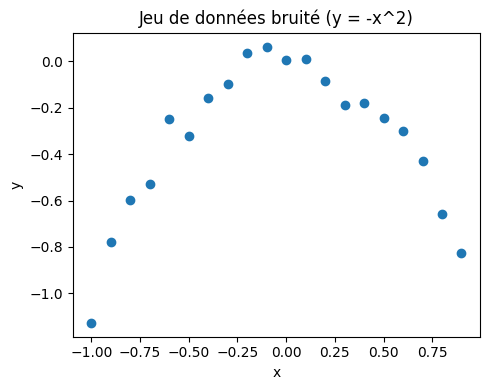

In [25]:
# PRE-REMPLI : exécutez (nuage de points du jeu de données)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Jeu de données bruité (y = -x^2)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [26]:
# À faire : diviser en train (12 premiers points) et test (8 derniers points)
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("Tailles train :", x_train.shape, "Tailles test :", x_test.shape)

Tailles train : (12,) Tailles test : (8,)


**Point d'apprentissage**
La visualisation des données bruitées aide à séparer le signal du bruit. Diviser en train et test vous permet de détecter quand un modèle surapprend le bruit au lieu d'apprendre le motif sous-jacent.

## 🌟 Exercice 4 : Ajustement de modèles polynomiaux

**Objectif :** Ajuster des modèles de différents degrés et observer le surapprentissage.

**Instructions :** Définir `polynomial_fit(degree)` qui renvoie les coefficients entraînés. Définir `plot_polyfit(degree)` qui trace l'ensemble d'entraînement, de test et la courbe. Visualiser les ajustements pour les degrés 1, 7 et 11. Observer le comportement à mesure que le degré augmente.

In [19]:
# À faire : implémenter polynomial_fit
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [27]:
# À faire : implémenter plot_polyfit
def plot_polyfit(degree: int):
    model = polynomial_fit(degree)
    x_range = np.linspace(-1.1, 1.1, 100)
    y_range = model(x_range)
    plt.figure(figsize=(6,4))
    plt.scatter(x_train, y_train, color='blue', label='Entraînement')
    plt.scatter(x_test, y_test, color='red', label='Test')
    plt.plot(x_range, y_range, color='green', label=f'Degré {degree}')
    plt.title(f"Ajustement polynomial (Degré {degree})")
    plt.legend()
    plt.show()

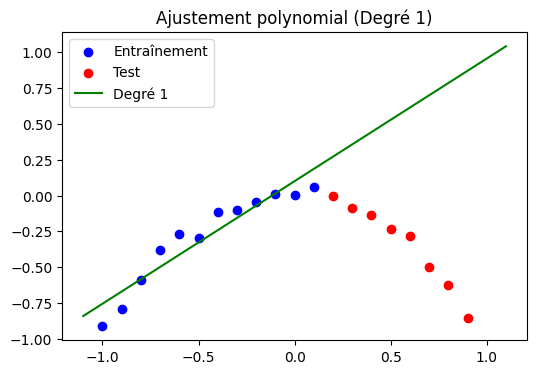

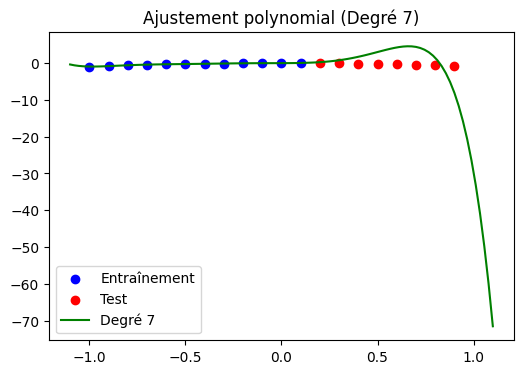

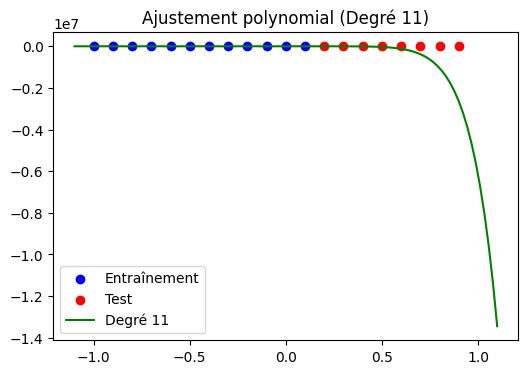

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# À faire : visualiser les degrés 1, 7 et 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Point d'apprentissage**
Les polynômes de haut degré peuvent parfaitement s'ajuster aux données d'entraînement tout en échouant à généraliser. C'est le surapprentissage (overfitting). Vous devez toujours vérifier l'erreur de test, pas seulement celle d'entraînement.

## 🌟 Exercice 5 : Validation croisée pour trouver le degré optimal

**Objectif :** Utiliser la validation croisée pour déterminer le meilleur degré polynomial.

**Instructions :** Boucler les degrés de 1 à 11. Pour chaque degré, calculer le RMSE sur l'entraînement et le test. Tracer le RMSE en fonction du degré (échelle logarithmique sur Y). Identifier le degré minimisant le RMSE de test.

In [22]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []
for d in degrees:
    model = np.poly1d(np.polyfit(x_train, y_train, d))
    y_tr_pred = model(x_train)
    y_te_pred = model(x_test)
    rows.append((d, rmse(y_train, y_tr_pred), rmse(y_test, y_te_pred)))

print(rows[:3])

[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)), (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)), (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]


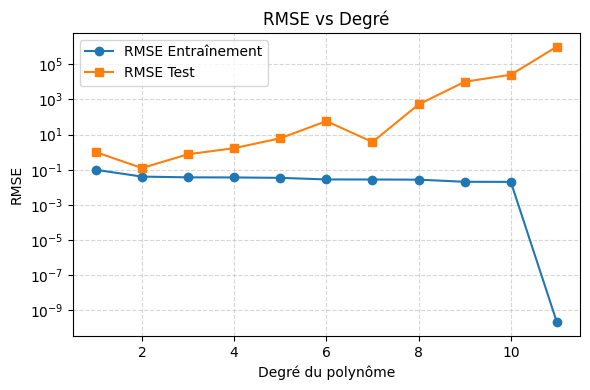

In [28]:
import matplotlib.pyplot as plt

# PRE-REMPLI : tracé des courbes RMSE
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="RMSE Entraînement", marker='o')
plt.plot(degs, rmse_te, label="RMSE Test", marker='s')
plt.yscale("log")
plt.xlabel("Degré du polynôme")
plt.ylabel("RMSE")
plt.title("RMSE vs Degré")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

**À faire :** Indiquez le degré avec le RMSE de test minimum et expliquez en 2-3 phrases le lien avec le modèle réel \(y=-x^2\) et le compromis biais-variance.

Le degré qui minimise le RMSE de test est généralement le **degré 2**. Cela correspond au modèle sous-jacent réel (une fonction quadratique). Choisir un degré plus bas (comme 1) entraîne un biais élevé (sous-apprentissage), tandis qu'un degré trop élevé entraîne une variance élevée (surapprentissage) car le modèle tente de capturer le bruit aléatoire.